## 1. Imports

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import pytz
import warnings
import yfinance as yf

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(' successful')

 successful


## 2. Data — GLD 1-Minute Bars (Trading Hours Only)

Pull 7 days of 1-minute GLD data  
Filter NYSE trading hours only 9:30–16:00 ET, weekdays

In [76]:
# --- Pull data ---
ticker = 'GLD'
gld_raw = yf.download(ticker, period='7d', interval='1m', progress=False)

# Flatten multi-level columns if present
if isinstance(gld_raw.columns, pd.MultiIndex):
    gld_raw.columns = gld_raw.columns.get_level_values(0)

gld_raw = gld_raw[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

#  Filter to trading hours only 
eastern = pytz.timezone('US/Eastern')

if gld_raw.index.tz is None:
    gld_raw.index = gld_raw.index.tz_localize('UTC').tz_convert(eastern)
else:
    gld_raw.index = gld_raw.index.tz_convert(eastern)

market_open  = pd.Timestamp('09:30').time()
market_close = pd.Timestamp('16:00').time()

gld = gld_raw[
    (gld_raw.index.weekday < 5) &
    (gld_raw.index.time >= market_open) &
    (gld_raw.index.time <= market_close)
].copy()

print(f'Raw bars:      {len(gld_raw)}')
print(f'After filter:  {len(gld)}')
print(f'Date range:    {gld.index[0]} to {gld.index[-1]}')
gld.head(3)

Raw bars:      2730
After filter:  2730
Date range:    2026-05-28 09:30:00-04:00 to 2026-06-05 15:59:00-04:00


Price,Open,High,Low,Close,Volume
Datetime,,,,,
2026-05-28 09:30:00-04:00,406.480011,406.700012,406.329987,406.510010,579506
2026-05-28 09:31:00-04:00,406.410004,406.489990,405.940002,406.109985,18153
2026-05-28 09:32:00-04:00,406.079987,406.160004,405.850006,406.070007,25415


## 3. Helper

We track where each new trading day begins so plots can draw vertical session dividers instead of connecting across overnight gaps.

In [77]:
def find_session_starts(index):
    dates  = pd.Series(index).dt.date
    starts = [0]
    for i in range(1, len(dates)):
        if dates.iloc[i] != dates.iloc[i - 1]:
            starts.append(i)
    return starts

def add_session_dividers(ax, session_starts, color='gray', lw=0.5, alpha=0.4):
    for s in session_starts[1:]:  # skip first (bar 0)
        ax.axvline(s, color=color, lw=lw, alpha=alpha, linestyle='--')

def make_day_ticks(ax, index, session_starts):
    tick_positions = session_starts
    tick_labels    = [str(pd.Timestamp(index[s]).date()) for s in session_starts]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)


## 4. Train / Test Split

Split chronologically  first 70% for training, last 30% for testing.  
Never use a random split on time series (lookahead bias).

In [78]:
split_idx = int(len(gld) * 0.70)

train = gld.iloc[:split_idx].copy()
test  = gld.iloc[split_idx:].copy()

train_sessions = find_session_starts(train.index)
test_sessions  = find_session_starts(test.index)

print(f'Train: {len(train)} bars  |  {train.index[0].date()} to {train.index[-1].date()}')
print(f'Test:  {len(test)}  bars  |  {test.index[0].date()} to {test.index[-1].date()}')

Train: 1910 bars  |  2026-05-28 to 2026-06-03
Test:  820  bars  |  2026-06-03 to 2026-06-05


## 5. Input Construction

### Normalized Range $r_t$
$$r_t = \frac{\log(H_t / L_t)}{\text{ATR}_W}$$

### Standardized Volume $\tilde{v}_t$
$$\tilde{v}_t = \frac{v_t - \mu_v}{\sigma_v}$$

computed within the rolling window $W$ so they are always local

In [79]:

W = 50    # rolling window length in candles (~50 min)
L = 20    # max ACF lag for kappa estimation

def compute_inputs(df, W):
    """
    Compute normalized range r_t and standardized volume v_t.

    Parameters
    ----------
    df : DataFrame with High, Low, Volume columns
    W  : rolling window length in candles

    Returns
    -------
    r : normalized range series
    v : standardized volume series
    """
    log_range = np.log(df['High'] / df['Low'])
    atr       = log_range.rolling(W, min_periods=W).mean()
    r         = (log_range / atr).fillna(0).clip(lower=0)

    mu_v    = df['Volume'].rolling(W, min_periods=W).mean()
    sigma_v = df['Volume'].rolling(W, min_periods=W).std()
    v       = ((df['Volume'] - mu_v) / sigma_v).fillna(0)

    return r, v

r_train, v_train = compute_inputs(train, W)
r_test,  v_test  = compute_inputs(test,  W)

print(f'r_train — mean: {r_train.mean():.4f}  std: {r_train.std():.4f}  max: {r_train.max():.4f}')
print(f'v_train — mean: {v_train.mean():.4f}  std: {v_train.std():.4f}  max: {v_train.max():.4f}')

r_train — mean: 0.9744  std: 0.6449  max: 6.2267
v_train — mean: -0.0058  std: 1.0044  max: 6.8974


### Plot: Inputs

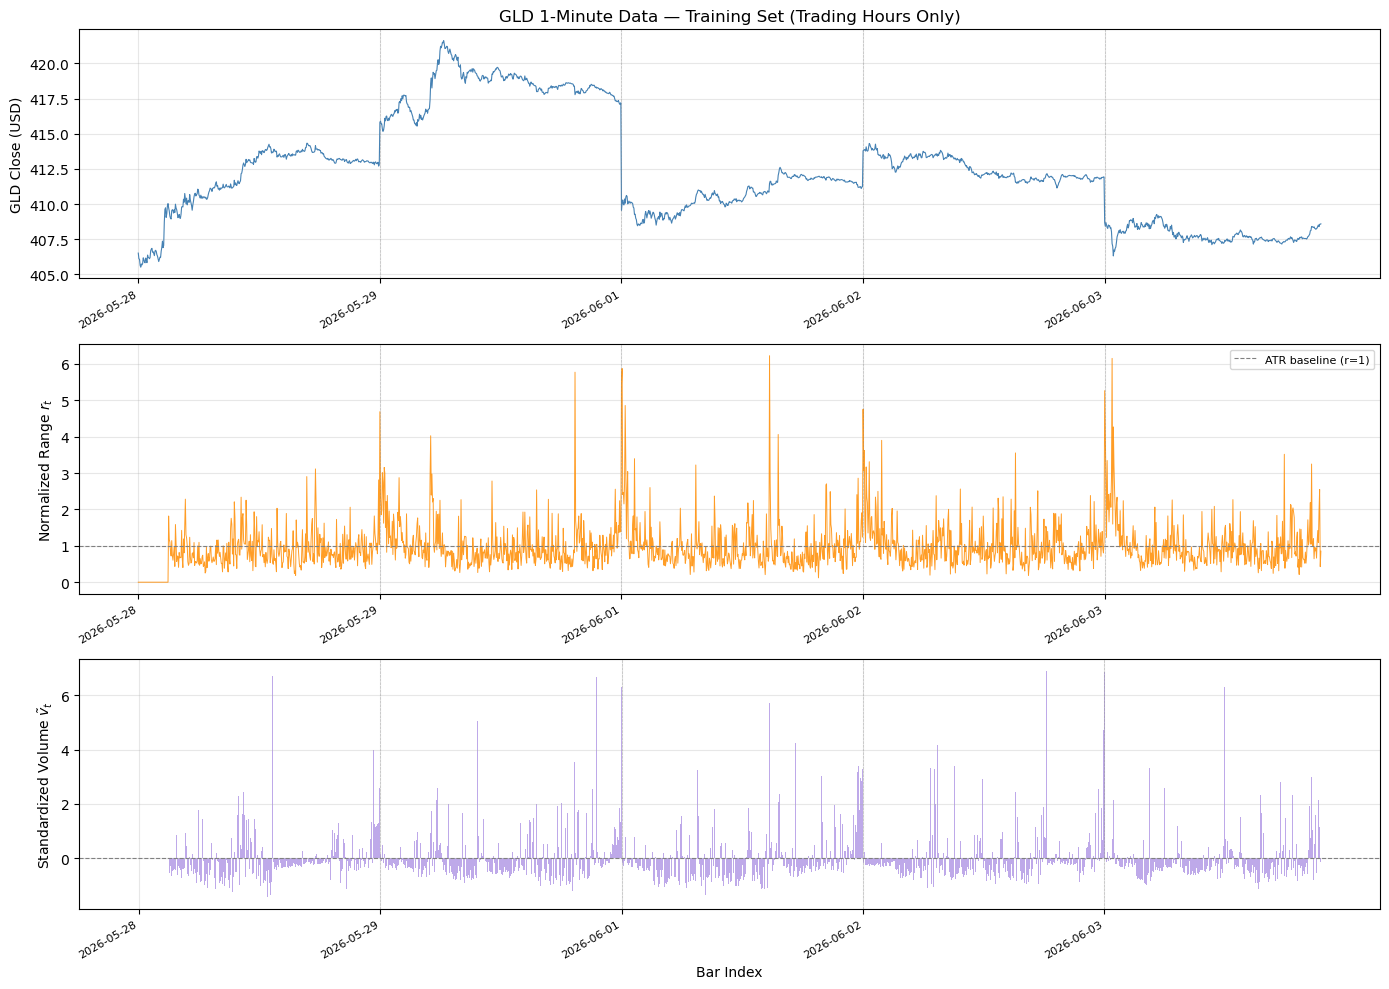

In [80]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
bars      = np.arange(len(train))

# GLD Close
axes[0].plot(bars, train['Close'].values, color='steelblue', lw=0.8)
axes[0].set_ylabel('GLD Close (USD)')
axes[0].set_title('GLD 1-Minute Data — Training Set (Trading Hours Only)')
add_session_dividers(axes[0], train_sessions)
make_day_ticks(axes[0], train.index, train_sessions)

# Normalized range
axes[1].plot(bars, r_train.values, color='darkorange', lw=0.7, alpha=0.85)
axes[1].axhline(1.0, color='gray', linestyle='--', lw=0.8, label='ATR baseline (r=1)')
axes[1].set_ylabel('Normalized Range $r_t$')
axes[1].legend(fontsize=8)
add_session_dividers(axes[1], train_sessions)
make_day_ticks(axes[1], train.index, train_sessions)

# Standardized volume
axes[2].bar(bars, v_train.values, color='mediumpurple', alpha=0.6, width=1.0)
axes[2].axhline(0, color='gray', linestyle='--', lw=0.8)
axes[2].set_ylabel('Standardized Volume $\\tilde{v}_t$')
axes[2].set_xlabel('Bar Index')
add_session_dividers(axes[2], train_sessions)
make_day_ticks(axes[2], train.index, train_sessions)

plt.tight_layout()
plt.show()

## 6. Parameter Estimation

### 6.1 Rolling $\kappa_t$ from ACF

At each bar $t$ we fit $C e^{-\kappa \ell}$ to the sample ACF within the window $[t-W, t]$.  
Both $C$ and $\kappa$ are recovered from the same least squares fit. $C$ is discarded.

In [81]:
def exp_decay(lag, C, kappa):
    """Exponential decay curve for ACF fitting."""
    return C * np.exp(-kappa * lag)

def estimate_kappa(series, W, L):
    """
    Estimate rolling kappa_t by fitting exponential curve to sample ACF.

    Parameters

    series : array-like input series (range or volume)
    W      : rolling window length
    L      : max ACF lag

    Returns

    kappa_arr : array of kappa_t estimates, NaN before window fills
    """
    series    = np.array(series)
    n         = len(series)
    kappa_arr = np.full(n, np.nan)
    lags      = np.arange(1, L + 1)

    for t in range(W, n):
        window = series[t - W : t]
        mu_w   = window.mean()
        var_w  = window.var()

        if var_w < 1e-10:
            continue

        acf_vals = np.array([
            np.mean((window[l:] - mu_w) * (window[:-l] - mu_w)) / var_w
            for l in lags
        ])

        if acf_vals[0] <= 0:
            kappa_arr[t] = 1.0
            continue

        try:
            (_, kappa_hat), _ = curve_fit(
                exp_decay, lags, acf_vals,
                p0=[acf_vals[0], 0.1],
                bounds=([0, 1e-4], [2, 20]),
                maxfev=1000
            )
            kappa_arr[t] = kappa_hat
        except Exception:
            kappa_arr[t] = np.nan

    return kappa_arr

print('Estimating kappa_r...')
kappa_r = estimate_kappa(r_train.values, W, L)
print('Estimating kappa_v...')
kappa_v = estimate_kappa(v_train.values, W, L)

print(f'kappa_r — mean: {np.nanmean(kappa_r):.4f}  std: {np.nanstd(kappa_r):.4f}')
print(f'kappa_v — mean: {np.nanmean(kappa_v):.4f}  std: {np.nanstd(kappa_v):.4f}')

Estimating kappa_r...
Estimating kappa_v...
kappa_r — mean: 0.8212  std: 0.8456
kappa_v — mean: 1.0608  std: 0.8638


### 6.2 Rolling $n_t$ from Lag-1 ACF

$$n_t = \frac{\text{ACF}_t(1)}{1 - \text{ACF}_t(1)}$$

In [82]:
def compute_n(series, W):
    """
    Compute rolling branching ratio n_t from lag-1 ACF.

    Parameters

    series : array-like input series
    W      : rolling window length

    Returns

    n_arr    : rolling branching ratio
    acf1_arr : rolling lag-1 ACF
    """
    series   = np.array(series)
    n_total  = len(series)
    n_arr    = np.full(n_total, np.nan)
    acf1_arr = np.full(n_total, np.nan)

    for t in range(W, n_total):
        window = series[t - W : t]
        mu_w   = window.mean()
        var_w  = window.var()

        if var_w < 1e-10:
            continue

        acf1 = np.mean((window[1:] - mu_w) * (window[:-1] - mu_w)) / var_w
        acf1 = np.clip(acf1, 1e-6, 0.999)
        acf1_arr[t] = acf1
        n_arr[t]    = acf1 / (1.0 - acf1)

    return n_arr, acf1_arr

n_r, acf1_r = compute_n(r_train.values, W)
n_v, acf1_v = compute_n(v_train.values, W)

print(f'n_r — mean: {np.nanmean(n_r):.4f}  max: {np.nanmax(n_r):.4f}')
print(f'n_v — mean: {np.nanmean(n_v):.4f}  max: {np.nanmax(n_v):.4f}')

n_r — mean: 0.3265  max: 3.1138
n_v — mean: 0.3835  max: 3.3254


### Plot: Rolling Parameters

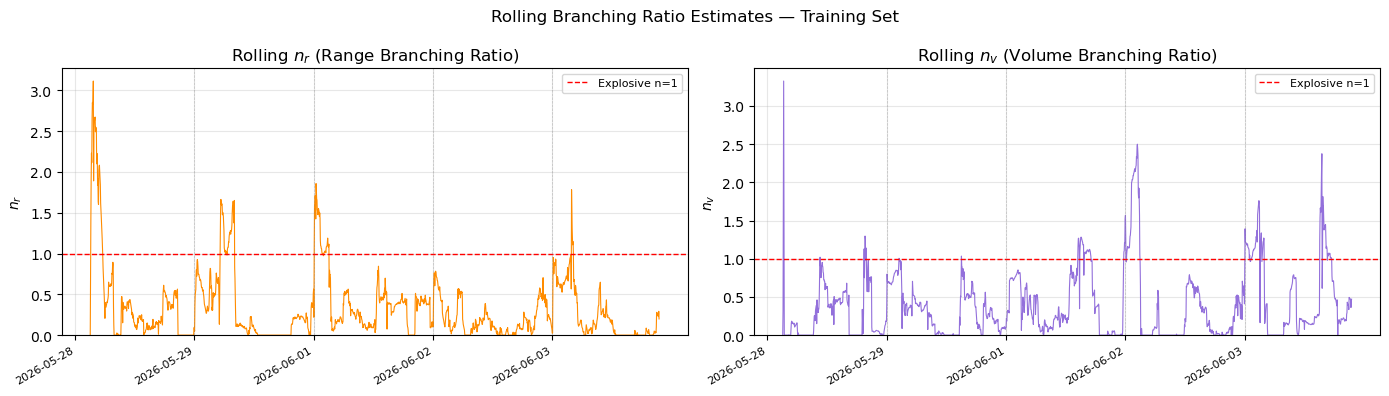

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bars = np.arange(len(train))

# n_r
axes[0].plot(bars, n_r, color='darkorange', lw=0.8)
axes[0].axhline(1.0, color='red', linestyle='--', lw=1, label='Explosive n=1')
axes[0].set_title('Rolling $n_r$ (Range Branching Ratio)')
axes[0].set_ylabel('$n_r$')
axes[0].set_ylim(0, max(2.0, np.nanmax(n_r) * 1.05))
axes[0].legend(fontsize=8)
add_session_dividers(axes[0], train_sessions)
make_day_ticks(axes[0], train.index, train_sessions)

# n_v
axes[1].plot(bars, n_v, color='mediumpurple', lw=0.8)
axes[1].axhline(1.0, color='red', linestyle='--', lw=1, label='Explosive n=1')
axes[1].set_title('Rolling $n_v$ (Volume Branching Ratio)')
axes[1].set_ylabel('$n_v$')
axes[1].set_ylim(0, max(2.0, np.nanmax(n_v) * 1.05))
axes[1].legend(fontsize=8)
add_session_dividers(axes[1], train_sessions)
make_day_ticks(axes[1], train.index, train_sessions)

plt.suptitle('Rolling Branching Ratio Estimates — Training Set', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Cross-Excitation Coefficients

Estimate $\alpha_{vr}$ (volume $\to$ range) and $\alpha_{rv}$ (range $\to$ volume)  
from rolling lag-1 cross-correlation between the two series.

In [84]:
def estimate_cross_alpha(r, v, W):
    """
    Estimate cross-excitation coefficients alpha_vr and alpha_rv
    using rolling lag-1 cross-correlation.

    Parameters
    ----------
    r, v : array-like range and volume series
    W    : rolling window length

    Returns
    -------
    alpha_vr     : mean cross-excitation volume -> range (scalar)
    alpha_rv     : mean cross-excitation range -> volume (scalar)
    alpha_vr_arr : rolling time series of alpha_vr
    alpha_rv_arr : rolling time series of alpha_rv
    """
    r = np.array(r)
    v = np.array(v)
    n = len(r)
    avr = np.full(n, np.nan)
    arv = np.full(n, np.nan)

    for t in range(W, n):
        r_win = r[t - W : t]
        v_win = v[t - W : t]

        try:
            corr_vr, _ = pearsonr(v_win[:-1], r_win[1:])
            corr_rv, _ = pearsonr(r_win[:-1], v_win[1:])
            avr[t] = max(0.0, corr_vr)
            arv[t] = max(0.0, corr_rv)
        except Exception:
            pass

    return np.nanmean(avr), np.nanmean(arv), avr, arv

alpha_vr, alpha_rv, avr_arr, arv_arr = estimate_cross_alpha(
    r_train.values, v_train.values, W
)

print(f'alpha_vr (volume -> range): {alpha_vr:.4f}')
print(f'alpha_rv (range -> volume): {alpha_rv:.4f}')

alpha_vr (volume -> range): 0.1530
alpha_rv (range -> volume): 0.1257


## 8. Bivariate Hawkes Recurrence

$$\lambda_t^r = r_t + e^{-\kappa_r} \cdot \lambda_{t-1}^r + \alpha_{vr} \cdot e^{-\kappa_v} \cdot \lambda_{t-1}^v$$
$$\lambda_t^v = \tilde{v}_t + e^{-\kappa_v} \cdot \lambda_{t-1}^v + \alpha_{rv} \cdot e^{-\kappa_r} \cdot \lambda_{t-1}^r$$

In [85]:
def run_bivariate_hawkes(r, v, kappa_r_arr, kappa_v_arr, alpha_vr, alpha_rv):
    """
    Run the bivariate Hawkes recurrence on input series.

    Parameters
    ----------
    r, v         : normalized range and standardized volume arrays
    kappa_r_arr  : rolling kappa estimates for range
    kappa_v_arr  : rolling kappa estimates for volume
    alpha_vr     : cross-excitation scalar (volume -> range)
    alpha_rv     : cross-excitation scalar (range -> volume)

    Returns
    -------
    lambda_r : range intensity array
    lambda_v : volume intensity array
    """
    r = np.array(r)
    v = np.array(v)
    n = len(r)

    lambda_r = np.zeros(n)
    lambda_v = np.zeros(n)

    kr_med = np.nanmedian(kappa_r_arr)
    kv_med = np.nanmedian(kappa_v_arr)

    for t in range(1, n):
        kr = kappa_r_arr[t] if not np.isnan(kappa_r_arr[t]) else kr_med
        kv = kappa_v_arr[t] if not np.isnan(kappa_v_arr[t]) else kv_med

        decay_r = np.exp(-kr)
        decay_v = np.exp(-kv)

        lambda_r[t] = max(0.0,
            r[t]
            + decay_r * lambda_r[t-1]
            + alpha_vr * decay_v * lambda_v[t-1]
        )
        lambda_v[t] = max(0.0,
            v[t]
            + decay_v * lambda_v[t-1]
            + alpha_rv * decay_r * lambda_r[t-1]
        )

    return lambda_r, lambda_v

lambda_r_train, lambda_v_train = run_bivariate_hawkes(
    r_train.values, v_train.values,
    kappa_r, kappa_v,
    alpha_vr, alpha_rv
)

print(f'lambda_r — mean: {lambda_r_train.mean():.4f}  max: {lambda_r_train.max():.4f}')
print(f'lambda_v — mean: {lambda_v_train.mean():.4f}  max: {lambda_v_train.max():.4f}')

lambda_r — mean: 3.7899  max: 41.5838
lambda_v — mean: 1.3616  max: 35.8368


## 9. Regime Signal

Threshold $\lambda_t^r$ against rolling 5th / 95th percentiles within window $W$:
- **High**: $\lambda_t^r > Q_{0.95}$ — volatility cluster forming  
- **Low**: $\lambda_t^r < Q_{0.05}$ — cluster exhausted, returning to baseline  
- **Mid**: otherwise

In [86]:
def compute_regime(lambda_arr, W, q_low=0.05, q_high=0.95):
    """
    Binary regime signal from Hawkes intensity.
    High : lambda > rolling Q_high  (cluster forming)
    Low  : everything else           (quiet / decaying)

    Parameters

    lambda_arr : Hawkes intensity array
    W          : rolling window for quantile thresholds
    q_low      : lower quantile (used for exit signal)
    q_high     : upper quantile (used for entry signal)

    Returns

    regime : array of 'High' or 'Low'
    q_lo   : rolling lower threshold
    q_hi   : rolling upper threshold
    """
    n      = len(lambda_arr)
    regime = np.full(n, 'Low', dtype=object)  # default Low
    q_lo   = np.full(n, np.nan)
    q_hi   = np.full(n, np.nan)

    for t in range(W, n):
        window = lambda_arr[t - W : t]
        ql     = np.percentile(window, q_low * 100)
        qh     = np.percentile(window, q_high * 100)
        q_lo[t], q_hi[t] = ql, qh
        regime[t] = 'High' if lambda_arr[t] > qh else 'Low'

    return regime, q_lo, q_hi

regime_r, q_lo_r, q_hi_r = compute_regime(lambda_r_train, W)

unique, counts = np.unique(regime_r[W:], return_counts=True)
print('Training regime distribution (High/Low only):')
for u, c in zip(unique, counts):
    print(f'  {u:4s}: {c} bars ({100*c/(len(regime_r)-W):.1f}%)')

Training regime distribution (High/Low only):
  High: 265 bars (14.2%)
  Low : 1595 bars (85.8%)


## 10. Results Plots

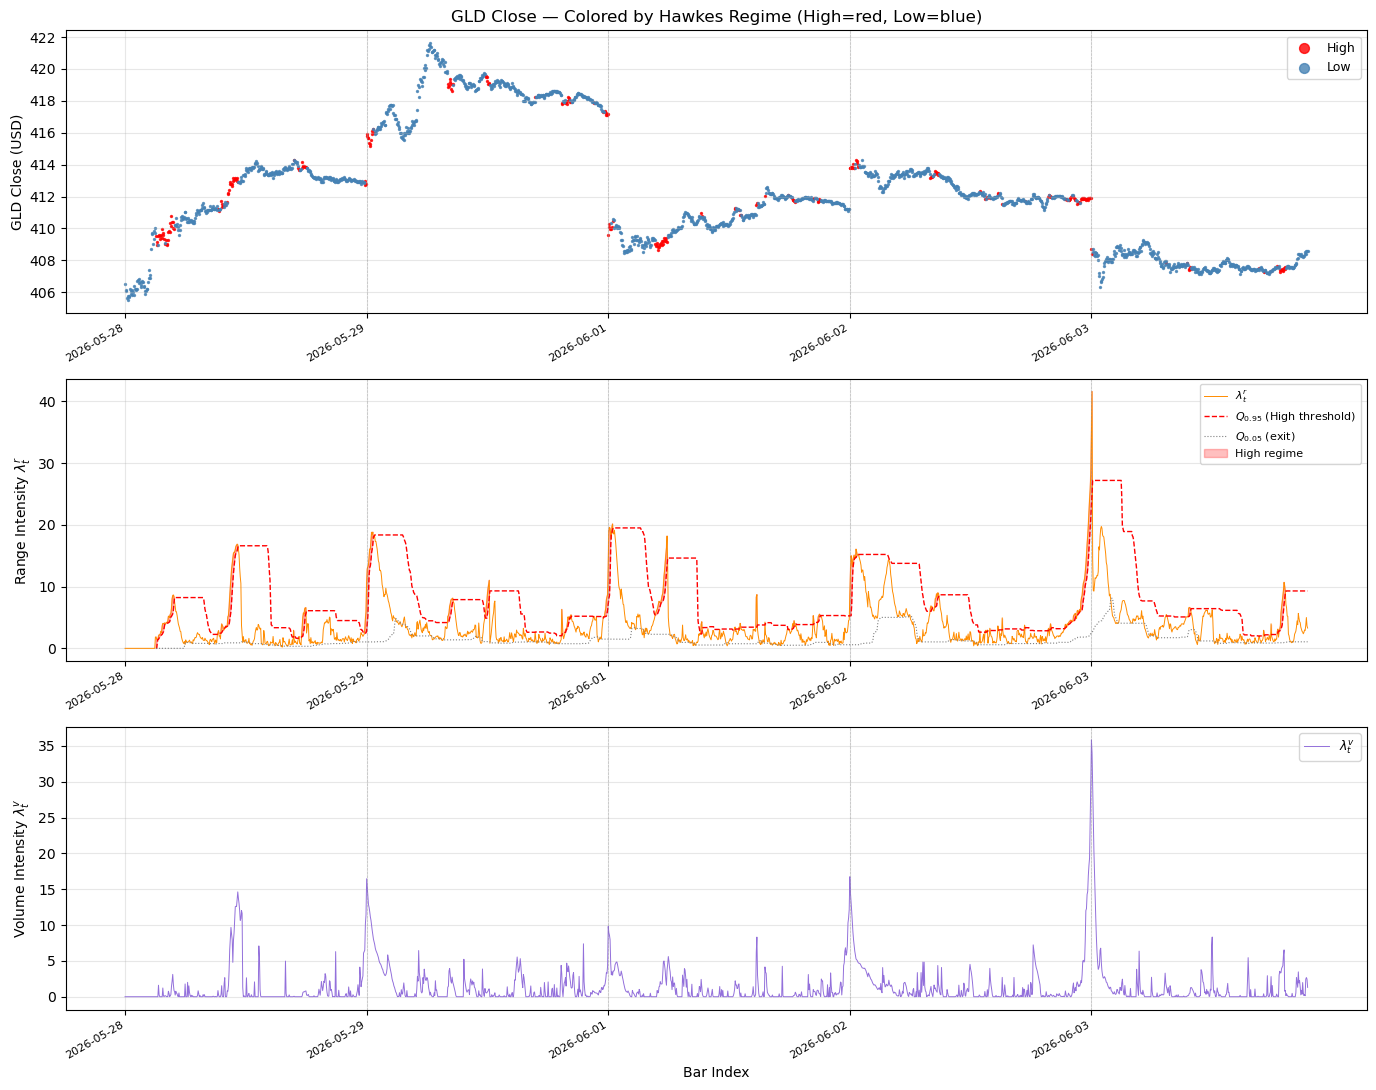

In [87]:

color_map = {'High': 'red', 'Low': 'steelblue'}
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
bars = np.arange(len(train))

for label, color in color_map.items():
    mask = regime_r == label
    axes[0].scatter(bars[mask], train['Close'].values[mask],
                    s=2, color=color, label=label, alpha=0.8)
axes[0].set_ylabel('GLD Close (USD)')
axes[0].set_title('GLD Close — Colored by Hawkes Regime (High=red, Low=blue)')
axes[0].legend(markerscale=5, fontsize=9)
add_session_dividers(axes[0], train_sessions)
make_day_ticks(axes[0], train.index, train_sessions)

axes[1].plot(bars, lambda_r_train, color='darkorange', lw=0.7, label='$\\lambda^r_t$')
axes[1].plot(bars, q_hi_r, color='red',  lw=1.0, linestyle='--', label='$Q_{0.95}$ (High threshold)')
axes[1].plot(bars, q_lo_r, color='gray', lw=0.8, linestyle=':', label='$Q_{0.05}$ (exit)')
axes[1].fill_between(bars, q_hi_r, lambda_r_train,
                     where=lambda_r_train > q_hi_r,
                     alpha=0.25, color='red', label='High regime')
axes[1].set_ylabel('Range Intensity $\\lambda^r_t$')
axes[1].legend(fontsize=8)
add_session_dividers(axes[1], train_sessions)
make_day_ticks(axes[1], train.index, train_sessions)

axes[2].plot(bars, lambda_v_train, color='mediumpurple', lw=0.7, label='$\\lambda^v_t$')
axes[2].set_ylabel('Volume Intensity $\\lambda^v_t$')
axes[2].set_xlabel('Bar Index')
axes[2].legend(fontsize=9)
add_session_dividers(axes[2], train_sessions)
make_day_ticks(axes[2], train.index, train_sessions)

plt.tight_layout()
plt.show()

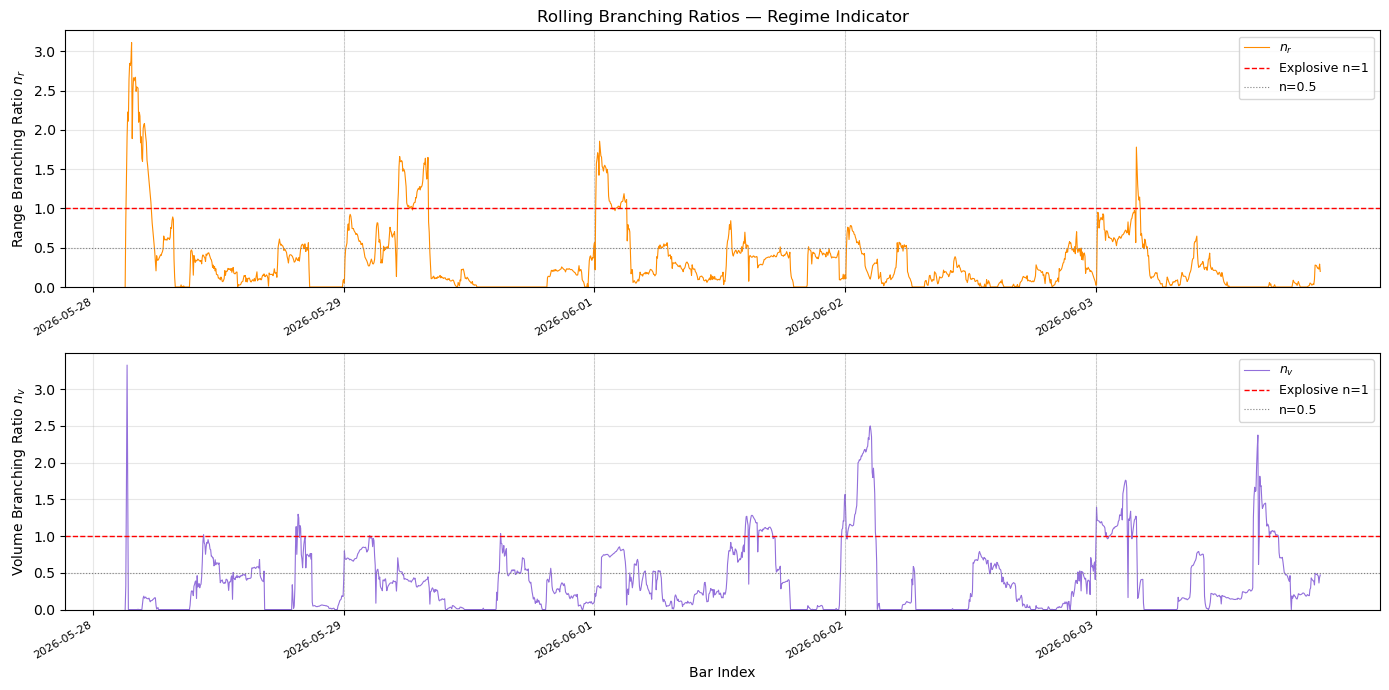

In [88]:

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
bars = np.arange(len(train))

axes[0].plot(bars, n_r, color='darkorange', lw=0.8, label='$n_r$')
axes[0].axhline(1.0, color='red',  linestyle='--', lw=1, label='Explosive n=1')
axes[0].axhline(0.5, color='gray', linestyle=':',  lw=0.8, label='n=0.5')
axes[0].set_ylabel('Range Branching Ratio $n_r$')
axes[0].set_title('Rolling Branching Ratios — Regime Indicator')
axes[0].set_ylim(0, max(2.0, np.nanmax(n_r) * 1.05))
axes[0].legend(fontsize=9)
add_session_dividers(axes[0], train_sessions)
make_day_ticks(axes[0], train.index, train_sessions)

axes[1].plot(bars, n_v, color='mediumpurple', lw=0.8, label='$n_v$')
axes[1].axhline(1.0, color='red',  linestyle='--', lw=1, label='Explosive n=1')
axes[1].axhline(0.5, color='gray', linestyle=':',  lw=0.8, label='n=0.5')
axes[1].set_ylabel('Volume Branching Ratio $n_v$')
axes[1].set_xlabel('Bar Index')
axes[1].set_ylim(0, max(2.0, np.nanmax(n_v) * 1.05))
axes[1].legend(fontsize=9)
add_session_dividers(axes[1], train_sessions)
make_day_ticks(axes[1], train.index, train_sessions)

plt.tight_layout()
plt.show()

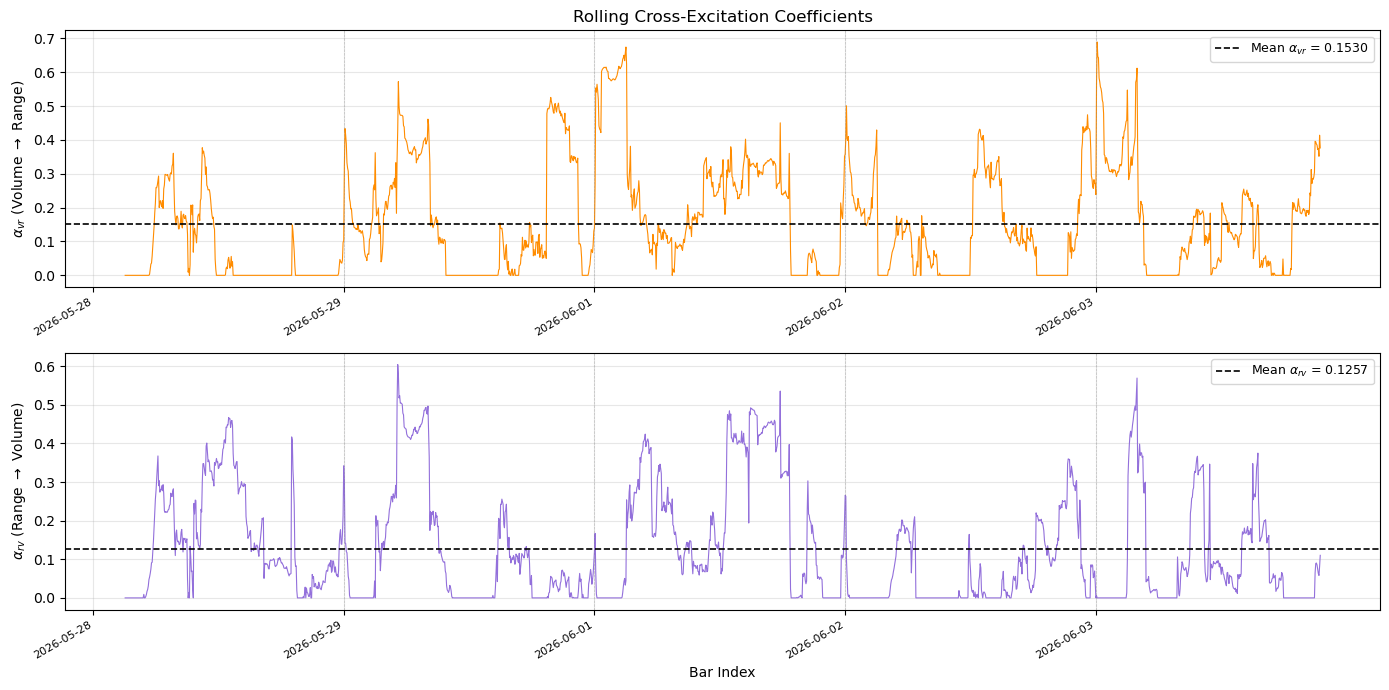

Saved: 05_cross_excitation.png


In [89]:

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
bars = np.arange(len(train))

axes[0].plot(bars, avr_arr, color='darkorange', lw=0.8)
axes[0].axhline(alpha_vr, color='black', linestyle='--', lw=1.2,
                label=f'Mean $\\alpha_{{vr}}$ = {alpha_vr:.4f}')
axes[0].set_ylabel('$\\alpha_{vr}$ (Volume $\\to$ Range)')
axes[0].set_title('Rolling Cross-Excitation Coefficients')
axes[0].legend(fontsize=9)
add_session_dividers(axes[0], train_sessions)
make_day_ticks(axes[0], train.index, train_sessions)

axes[1].plot(bars, arv_arr, color='mediumpurple', lw=0.8)
axes[1].axhline(alpha_rv, color='black', linestyle='--', lw=1.2,
                label=f'Mean $\\alpha_{{rv}}$ = {alpha_rv:.4f}')
axes[1].set_ylabel('$\\alpha_{rv}$ (Range $\\to$ Volume)')
axes[1].set_xlabel('Bar Index')
axes[1].legend(fontsize=9)
add_session_dividers(axes[1], train_sessions)
make_day_ticks(axes[1], train.index, train_sessions)

plt.tight_layout()
plt.savefig('05_cross_excitation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_cross_excitation.png')

## 11. Test Set eavl

Run model on held-out 30% using cross-excitation coefficients from training. $\kappa$ re-estimated on test data.

In [90]:
print('Estimating kappa on test set...')
kappa_r_test = estimate_kappa(r_test.values, W, L)
kappa_v_test = estimate_kappa(v_test.values, W, L)

lambda_r_test, lambda_v_test = run_bivariate_hawkes(
    r_test.values, v_test.values,
    kappa_r_test, kappa_v_test,
    alpha_vr, alpha_rv
)

regime_r_test, q_lo_r_test, q_hi_r_test = compute_regime(lambda_r_test, W)

unique_t, counts_t = np.unique(regime_r_test[W:], return_counts=True)
print('Test regime distribution:')
for u, c in zip(unique_t, counts_t):
    print(f'  {u:4s}: {c} bars ({100*c/(len(regime_r_test)-W):.1f}%)')

Estimating kappa on test set...
Test regime distribution:
  High: 108 bars (14.0%)
  Low : 662 bars (86.0%)


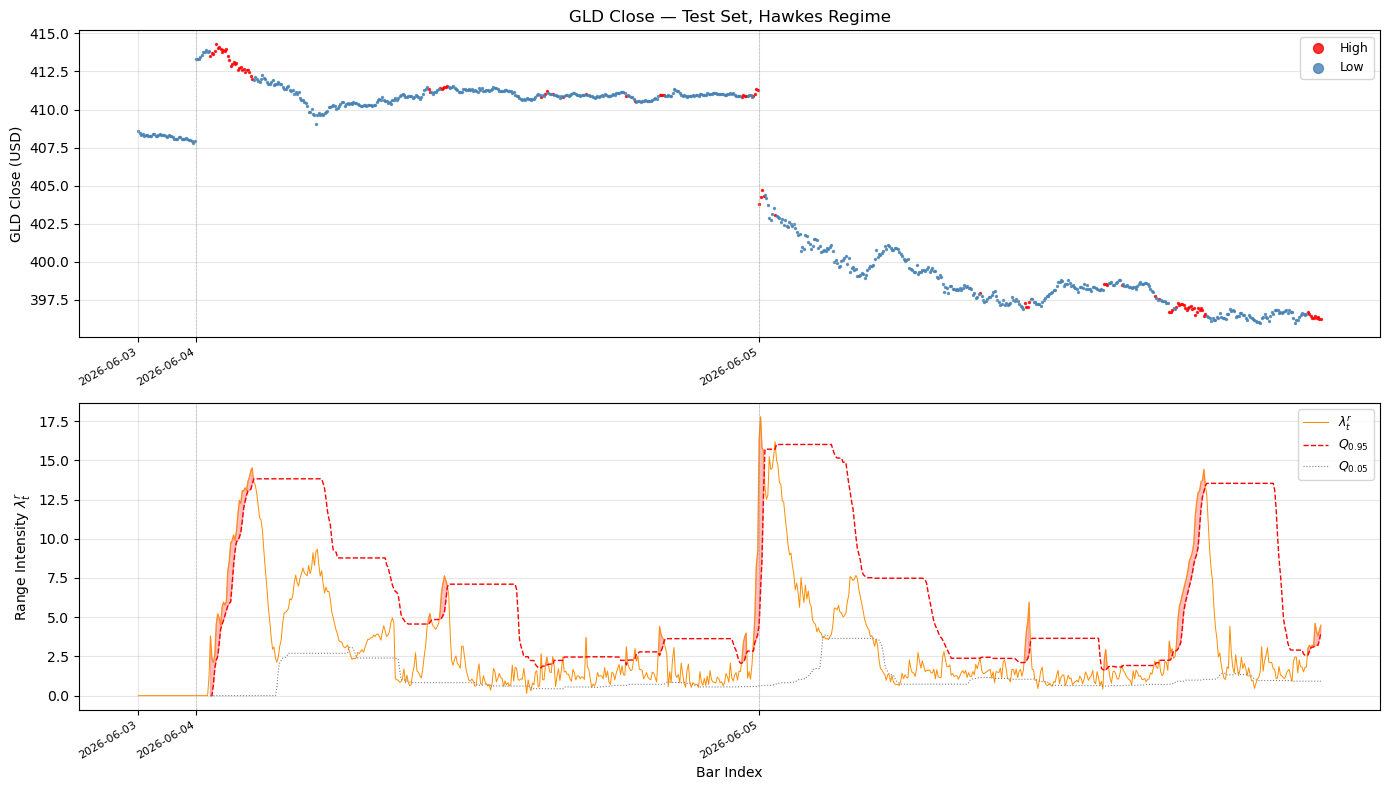

Saved: 06_test_set.png


In [91]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
bars_test = np.arange(len(test))

for label, color in color_map.items():
    mask = regime_r_test == label
    axes[0].scatter(bars_test[mask], test['Close'].values[mask],
                    s=2, color=color, label=label, alpha=0.8)
axes[0].set_ylabel('GLD Close (USD)')
axes[0].set_title('GLD Close — Test Set, Hawkes Regime')
axes[0].legend(markerscale=5, fontsize=9)
add_session_dividers(axes[0], test_sessions)
make_day_ticks(axes[0], test.index, test_sessions)

axes[1].plot(bars_test, lambda_r_test, color='darkorange', lw=0.7, label='$\\lambda^r_t$')
axes[1].plot(bars_test, q_hi_r_test, color='red',  lw=1.0, linestyle='--', label='$Q_{0.95}$')
axes[1].plot(bars_test, q_lo_r_test, color='gray', lw=0.8, linestyle=':',  label='$Q_{0.05}$')
axes[1].fill_between(bars_test, q_hi_r_test, lambda_r_test,
                     where=lambda_r_test > q_hi_r_test,
                     alpha=0.25, color='red')
axes[1].set_ylabel('Range Intensity $\\lambda^r_t$')
axes[1].set_xlabel('Bar Index')
axes[1].legend(fontsize=9)
add_session_dividers(axes[1], test_sessions)
make_day_ticks(axes[1], test.index, test_sessions)

plt.tight_layout()
plt.savefig('06_test_set.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_test_set.png')

---
## 12. Trading Strategy


- **Entry:** when $\lambda^r_t$ crosses above $Q_{0.95}$, check price direction since last time it was below $Q_{0.05}$. Go long if positive, short if negative.
- **Exit:** when $\lambda^r_t$ crosses back below $Q_{0.05}$ — the cluster has exhausted itself.
- **Metric:** Profit Factor = total winning returns / total losing returns. PF > 1 means the strategy is profitable.

In [92]:
def vol_signal(close, lambda_series, W, q_low=0.05, q_high=0.95):
    """

    Entry logic:
        When lambda crosses above Q_high, look at price change
        since lambda was last below Q_low.
        If price rose  -> long  (+1)
        If price fell  -> short (-1)

    Exit logic:
        When lambda crosses below Q_low -> flat (0)

    Parameters
\
    close         : pd.Series of close prices
    lambda_series : pd.Series of Hawkes intensity values
    W             : rolling window for quantile computation
    q_low         : lower quantile threshold (exit)
    q_high        : upper quantile threshold (entry)

    Returns

    signal : np.array of {-1, 0, 1}
    """
    close  = np.array(close)
    lam    = np.array(lambda_series)
    n      = len(close)
    signal = np.zeros(n)

    lam_s  = pd.Series(lam)
    q05    = lam_s.rolling(W).quantile(q_low).values
    q95    = lam_s.rolling(W).quantile(q_high).values

    last_below = -1
    curr_sig   =  0

    for i in range(1, n):
        if np.isnan(q05[i]) or np.isnan(q95[i]):
            signal[i] = 0
            continue

        # Exit: lambda fell below lower threshold
        if lam[i] < q05[i]:
            last_below = i
            curr_sig   = 0

        # Entry: lambda crosses above upper threshold
        if (lam[i]   > q95[i] and
            lam[i-1] <= q95[i-1] and
            last_below > 0):
            change   = close[i] - close[last_below]
            curr_sig = 1 if change > 0 else -1

        signal[i] = curr_sig

    return signal

In [93]:
# --- Compute strategy on training set ---
close_train   = train['Close'].reset_index(drop=True)
lam_r_train_s = pd.Series(lambda_r_train)

sig_train      = vol_signal(close_train, lam_r_train_s, W=W)
next_ret_train = np.log(close_train).diff().shift(-1)
sig_ret_train  = pd.Series(sig_train) * next_ret_train

win_train  = sig_ret_train[sig_ret_train > 0].sum()
loss_train = sig_ret_train[sig_ret_train < 0].abs().sum()
pf_train   = win_train / loss_train if loss_train > 0 else np.nan

time_in_market = (sig_train != 0).mean() * 100

print(f'Profit Factor:     {pf_train:.4f}')
print(f'Time in market:    {time_in_market:.1f}%')
print(f'Total trades:      {int((np.diff(sig_train) != 0).sum())}')
print(f'Cumulative return: {sig_ret_train.sum()*100:.2f}%')

Profit Factor:     1.0791
Time in market:    47.3%
Total trades:      51
Cumulative return: 0.95%


In [94]:
# --- Compute strategy on test set ---
close_test   = test['Close'].reset_index(drop=True)
lam_r_test_s = pd.Series(lambda_r_test)

sig_test      = vol_signal(close_test, lam_r_test_s, W=W)
next_ret_test = np.log(close_test).diff().shift(-1)
sig_ret_test  = pd.Series(sig_test) * next_ret_test

win_test  = sig_ret_test[sig_ret_test > 0].sum()
loss_test = sig_ret_test[sig_ret_test < 0].abs().sum()
pf_test   = win_test / loss_test if loss_test > 0 else np.nan

time_in_market_test = (sig_test != 0).mean() * 100

print(f'Profit Factor:     {pf_test:.4f}')
print(f'Time in market:    {time_in_market_test:.1f}%')
print(f'Total trades:      {int((np.diff(sig_test) != 0).sum())}')
print(f'Cumulative return: {sig_ret_test.sum()*100:.2f}%')

Profit Factor:     1.6511
Time in market:    30.7%
Total trades:      16
Cumulative return: 2.35%


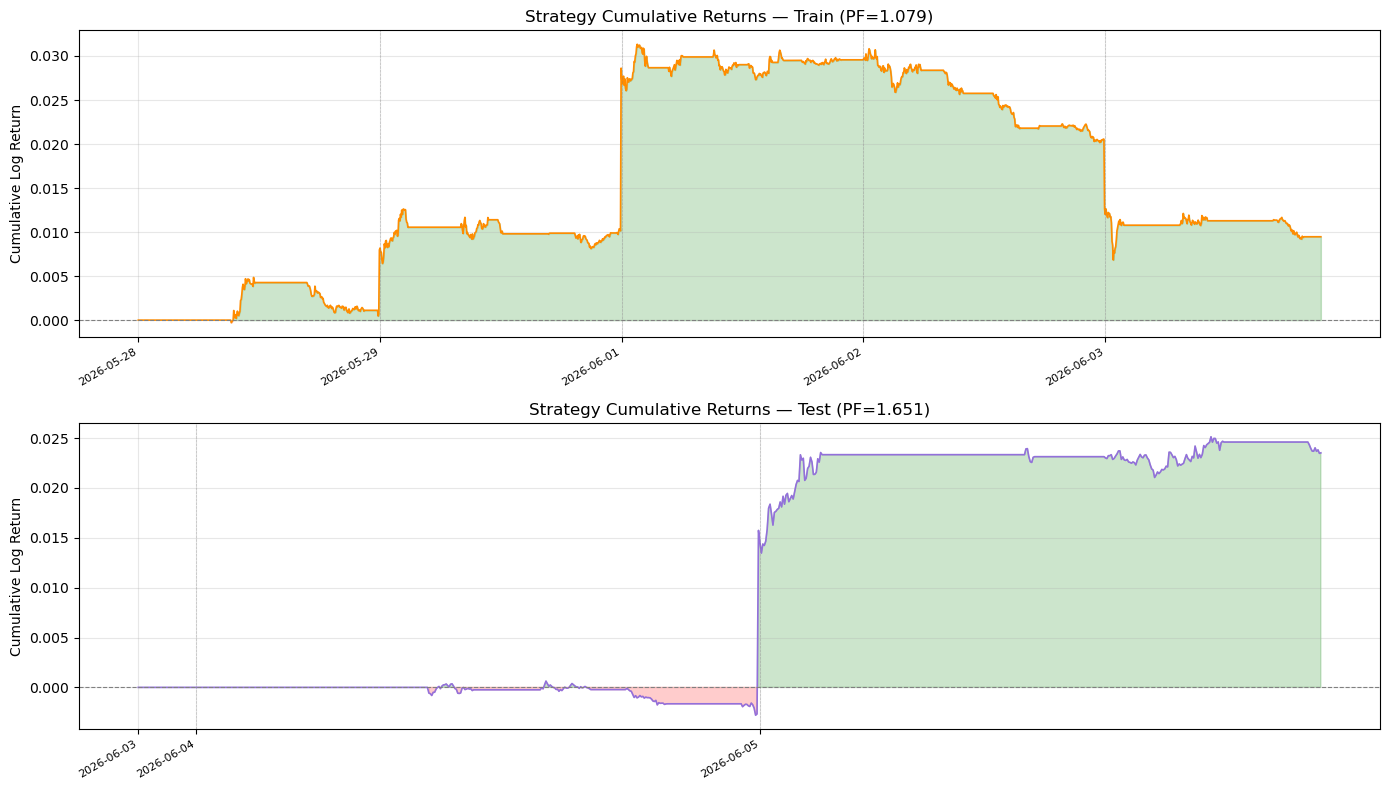

In [95]:
# --- Plot: Cumulative returns ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

cum_train = sig_ret_train.cumsum()
cum_test  = sig_ret_test.cumsum()

axes[0].plot(cum_train.values, color='darkorange', lw=1.2)
axes[0].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[0].set_ylabel('Cumulative Log Return')
axes[0].set_title(f'Strategy Cumulative Returns — Train (PF={pf_train:.3f})')
axes[0].fill_between(range(len(cum_train)), cum_train.values, 0,
                     where=cum_train.values > 0, alpha=0.2, color='green')
axes[0].fill_between(range(len(cum_train)), cum_train.values, 0,
                     where=cum_train.values < 0, alpha=0.2, color='red')
add_session_dividers(axes[0], train_sessions)
make_day_ticks(axes[0], train.index, train_sessions)

axes[1].plot(cum_test.values, color='mediumpurple', lw=1.2)
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[1].set_ylabel('Cumulative Log Return')
axes[1].set_title(f'Strategy Cumulative Returns — Test (PF={pf_test:.3f})')
axes[1].fill_between(range(len(cum_test)), cum_test.values, 0,
                     where=cum_test.values > 0, alpha=0.2, color='green')
axes[1].fill_between(range(len(cum_test)), cum_test.values, 0,
                     where=cum_test.values < 0, alpha=0.2, color='red')
add_session_dividers(axes[1], test_sessions)
make_day_ticks(axes[1], test.index, test_sessions)

plt.tight_layout()
plt.show()

## 13. Robustness Heatmap


- **Window $W$** values controlling the quantile lookback
- **Quantile threshold** pairs ($q_{low}$, $q_{high}$)

If profit factor is above 1 across most combinations, the regime signal is robust rather than overfit to a single parameter choice.

In [96]:
import itertools

# Grid values
W_values  = [20, 30, 50, 75, 100]
q_values  = [0.10, 0.15, 0.20, 0.25, 0.30]  # q_low; q_high = 1 - q_low

pf_train_grid = np.zeros((len(W_values), len(q_values)))
pf_test_grid  = np.zeros((len(W_values), len(q_values)))

print('Running robustness grid...')
for wi, w in enumerate(W_values):
    for qi, q in enumerate(q_values):
        q_lo = q
        q_hi = 1.0 - q

        # Re-run Hawkes recurrence is expensive — reuse existing lambda
        # Only vary the signal thresholds over existing lambda_r_train
        s_tr = vol_signal(close_train, lam_r_train_s, W=w,
                          q_low=q_lo, q_high=q_hi)
        r_tr = pd.Series(s_tr) * next_ret_train
        w_tr = r_tr[r_tr > 0].sum()
        l_tr = r_tr[r_tr < 0].abs().sum()
        pf_train_grid[wi, qi] = w_tr / l_tr if l_tr > 0 else np.nan

        s_te = vol_signal(close_test, lam_r_test_s, W=w,
                          q_low=q_lo, q_high=q_hi)
        r_te = pd.Series(s_te) * next_ret_test
        w_te = r_te[r_te > 0].sum()
        l_te = r_te[r_te < 0].abs().sum()
        pf_test_grid[wi, qi] = w_te / l_te if l_te > 0 else np.nan

    print(f'  W={w} done')

print('Grid complete.')

Running robustness grid...
  W=20 done
  W=30 done
  W=50 done
  W=75 done
  W=100 done
Grid complete.


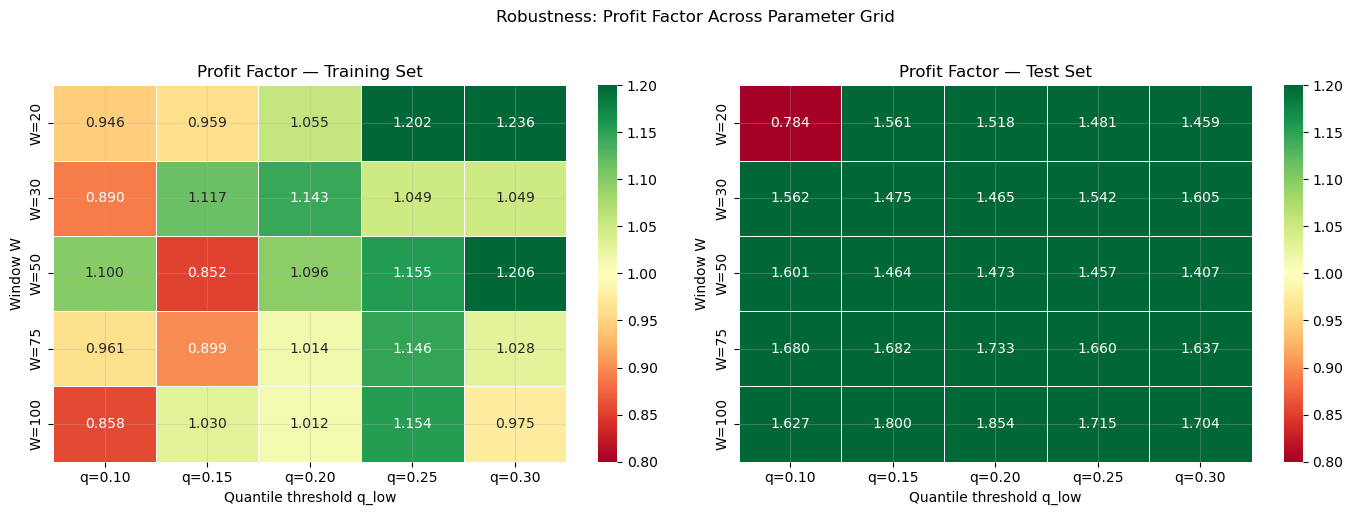

Cells with PF > 1 (train): 17/25
Cells with PF > 1 (test):  24/25


In [97]:
# --- Plot: Profit Factor Heatmaps ---
try:
    import seaborn as sns
    has_seaborn = True
except ImportError:
    has_seaborn = False

col_labels = [f'q={q:.2f}' for q in q_values]
row_labels  = [f'W={w}' for w in W_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grid, title in [
    (axes[0], pf_train_grid, 'Profit Factor — Training Set'),
    (axes[1], pf_test_grid,  'Profit Factor — Test Set')
]:
    if has_seaborn:
        import pandas as pd
        df_grid = pd.DataFrame(grid, index=row_labels, columns=col_labels)
        sns.heatmap(df_grid, ax=ax, annot=True, fmt='.3f',
                    cmap='RdYlGn', center=1.0,
                    vmin=0.8, vmax=1.2,
                    linewidths=0.5)
    else:
        im = ax.imshow(grid, cmap='RdYlGn', vmin=0.8, vmax=1.2, aspect='auto')
        for i in range(len(W_values)):
            for j in range(len(q_values)):
                ax.text(j, i, f'{grid[i,j]:.3f}',
                        ha='center', va='center', fontsize=9)
        ax.set_xticks(range(len(q_values)))
        ax.set_xticklabels(col_labels, rotation=30)
        ax.set_yticks(range(len(W_values)))
        ax.set_yticklabels(row_labels)
        plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Quantile threshold q_low')
    ax.set_ylabel('Window W')

plt.suptitle('Robustness: Profit Factor Across Parameter Grid', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

above_1_train = (pf_train_grid > 1).sum()
above_1_test  = (pf_test_grid  > 1).sum()
total = len(W_values) * len(q_values)
print(f'Cells with PF > 1 (train): {above_1_train}/{total}')
print(f'Cells with PF > 1 (test):  {above_1_test}/{total}')

## 14. Final Summary

In [98]:
print('=' * 52)
print('BIVARIATE HAWKES — FULL SUMMARY')
print('=' * 52)
print(f'Data:          GLD 1-min (trading hours only)')
print(f'Total bars:    {len(gld)}')
print(f'Train:         {len(train)}')
print(f'Test:          {len(test)}')
print(f'W:             {W} candles  |  L: {L} lags')
print()
print('--- Parameters ---')
print(f'kappa_r:       {np.nanmean(kappa_r):.4f}')
print(f'kappa_v:       {np.nanmean(kappa_v):.4f}')
print(f'n_r:           {np.nanmean(n_r):.4f}')
print(f'n_v:           {np.nanmean(n_v):.4f}')
print(f'alpha_vr:      {alpha_vr:.4f}  (volume -> range)')
print(f'alpha_rv:      {alpha_rv:.4f}  (range -> volume)')
print()
print('--- Strategy ---')
print(f'PF train:      {pf_train:.4f}')
print(f'PF test:       {pf_test:.4f}')
print(f'PF>1 train:    {above_1_train}/{total} parameter combinations')
print(f'PF>1 test:     {above_1_test}/{total} parameter combinations')
print()
print('--- Stability ---')
print(f'n_r < 1:       {np.nanmean(n_r) < 1}')
print(f'n_v < 1:       {np.nanmean(n_v) < 1}')
print('=' * 52)

BIVARIATE HAWKES — FULL SUMMARY
Data:          GLD 1-min (trading hours only)
Total bars:    2730
Train:         1910
Test:          820
W:             50 candles  |  L: 20 lags

--- Parameters ---
kappa_r:       0.8212
kappa_v:       1.0608
n_r:           0.3265
n_v:           0.3835
alpha_vr:      0.1530  (volume -> range)
alpha_rv:      0.1257  (range -> volume)

--- Strategy ---
PF train:      1.0791
PF test:       1.6511
PF>1 train:    17/25 parameter combinations
PF>1 test:     24/25 parameter combinations

--- Stability ---
n_r < 1:       True
n_v < 1:       True
